In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [3]:
nav = pd.read_csv("../data/processed/clean_nav_history.csv")

performance = pd.read_csv("../data/processed/clean_scheme_performance.csv")

transactions = pd.read_csv("../data/processed/clean_investor_transactions.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [4]:
nav["date"] = pd.to_datetime(nav["date"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [5]:
nav = nav.merge(
    performance[
        ["amfi_code", "scheme_name", "risk_grade"]
    ],
    on="amfi_code",
    how="left"
)

In [6]:
nav = nav.sort_values(
    ["scheme_name", "date"]
)

nav["daily_return"] = (
    nav.groupby("scheme_name")["nav"]
       .pct_change()
)

In [7]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [8]:
var = (
    nav.groupby("scheme_name")["daily_return"]
       .quantile(0.05)
       .reset_index()
)

var.columns = ["scheme_name", "VaR_95"]

var.head()

,scheme_name,VaR_95
0,ABSL Frontline Equity Fund - Regular - Growth,-0.013282
1,ABSL Liquid Fund - Regular - Growth,-0.000269
2,ABSL Small Cap Fund - Regular - Growth,-0.026021
3,Axis Bluechip Fund - Direct - Growth,-0.014226
4,Axis Bluechip Fund - Regular - Growth,-0.013750


In [9]:
cvar_list = []

for fund in nav["scheme_name"].unique():

    temp = nav[nav["scheme_name"] == fund]

    threshold = temp["daily_return"].quantile(0.05)

    cvar = temp[temp["daily_return"] <= threshold]["daily_return"].mean()

    cvar_list.append([fund, cvar])

cvar = pd.DataFrame(
    cvar_list,
    columns=["scheme_name", "CVaR_95"]
)

cvar.head()

,scheme_name,CVaR_95
0,ABSL Frontline Equity Fund - Regular - Growth,-0.017439
1,ABSL Liquid Fund - Regular - Growth,-0.000422
2,ABSL Small Cap Fund - Regular - Growth,-0.032459
3,Axis Bluechip Fund - Direct - Growth,-0.017487
4,Axis Bluechip Fund - Regular - Growth,-0.017328


In [10]:
risk_report = var.merge(cvar, on="scheme_name")

risk_report.head()

,scheme_name,VaR_95,CVaR_95
0,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
1,ABSL Liquid Fund - Regular - Growth,-0.000269,-0.000422
2,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
3,Axis Bluechip Fund - Direct - Growth,-0.014226,-0.017487
4,Axis Bluechip Fund - Regular - Growth,-0.013750,-0.017328


In [11]:
risk_report = risk_report.sort_values("VaR_95")

risk_report.head(10)

,scheme_name,VaR_95,CVaR_95
35,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384
6,Axis Small Cap Fund - Regular - Growth,-0.026188,-0.031667
2,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
31,Nippon India Small Cap Fund - Regular - Growth,-0.025438,-0.032304
36,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595
8,DSP Small Cap Fund - Regular - Growth,-0.023483,-0.031036
38,UTI Mid Cap Fund - Regular - Growth,-0.019220,-0.023251
11,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
18,ICICI Pru Midcap Fund - Regular - Growth,-0.018892,-0.024342
5,Axis Midcap Fund - Regular - Growth,-0.018480,-0.024260


In [12]:
risk_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

In [13]:
risk_report.head()

,scheme_name,VaR_95,CVaR_95
35,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384
6,Axis Small Cap Fund - Regular - Growth,-0.026188,-0.031667
2,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
31,Nippon India Small Cap Fund - Regular - Growth,-0.025438,-0.032304
36,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595


In [14]:
rf_daily = 0.065 / 252

nav["rolling_sharpe"] = (
    (
        nav.groupby("scheme_name")["daily_return"]
        .transform(lambda x: x.rolling(90).mean())
        - rf_daily
    )
    /
    nav.groupby("scheme_name")["daily_return"]
    .transform(lambda x: x.rolling(90).std())
) * np.sqrt(252)

In [15]:
top5 = [
    "Mirae Asset Large Cap Fund - Regular - Growth",
    "ICICI Pru Midcap Fund - Regular - Growth",
    "Kotak Flexicap Fund - Regular - Growth",
    "HDFC Mid-Cap Opportunities Fund - Regular - Growth",
    "SBI Bluechip Fund - Regular Plan - Growth"
]

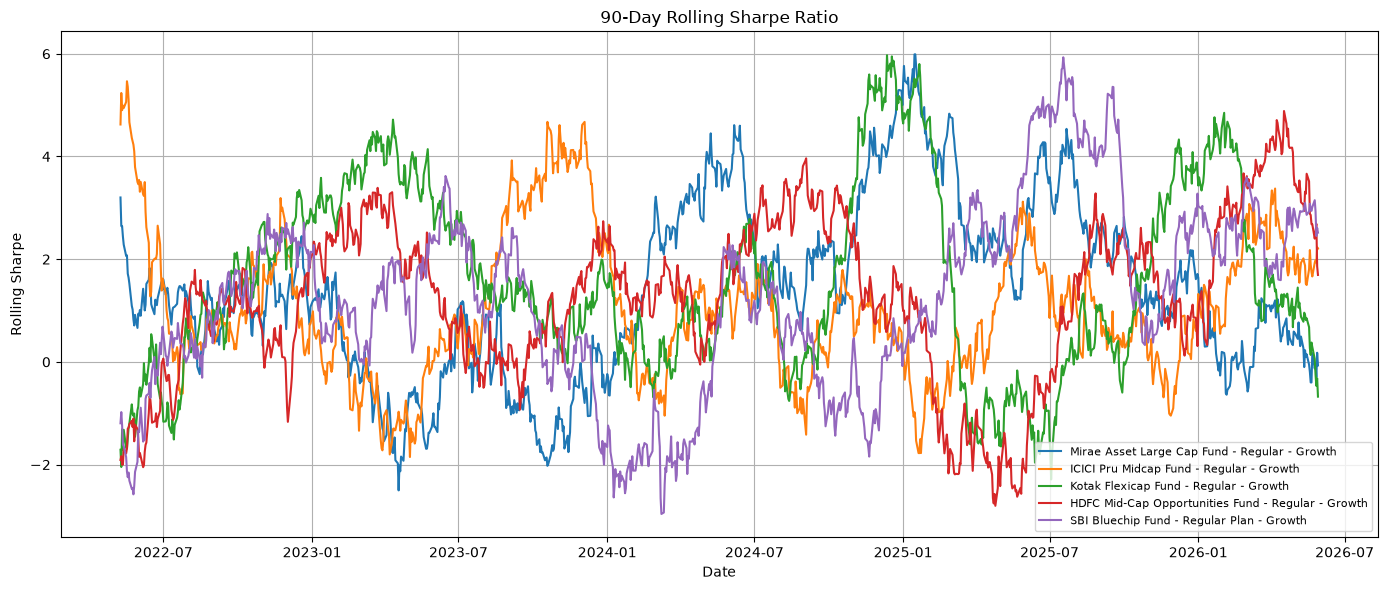

In [16]:
plt.figure(figsize=(14,6))

for fund in top5:
    temp = nav[nav["scheme_name"] == fund]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=fund
    )

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe")

plt.legend(fontsize=8)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/charts/rolling_sharpe_chart.png",
    dpi=300
)

plt.show()

In [17]:
import os

os.path.exists("../reports/charts/rolling_sharpe_chart.png")

True

In [18]:
transactions["first_year"] = (
    transactions.groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.year
)

transactions[["investor_id","first_year"]].head()

,investor_id,first_year
0,INV003054,2024
1,INV002952,2024
2,INV003420,2024
3,INV003436,2024
4,INV004691,2024


In [19]:
sip = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

In [20]:
avg_sip = (
    sip.groupby("first_year")["amount_inr"]
    .mean()
    .reset_index(name="Average_SIP")
)

avg_sip

,first_year,Average_SIP
0,2024,10996.885825
1,2025,13505.209581


In [21]:
total_investment = (
    sip.groupby("first_year")["amount_inr"]
    .sum()
    .reset_index(name="Total_Invested")
)

total_investment

,first_year,Total_Invested
0,2024,214978121
1,2025,2255370


In [22]:
top_fund = (
    sip.groupby(["first_year","amfi_code"])
       .size()
       .reset_index(name="Count")
)

top_fund = (
    top_fund.sort_values(
        "Count",
        ascending=False
    )
    .drop_duplicates("first_year")
)

In [23]:
top_fund = top_fund.merge(
    performance[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

top_fund.head()

,first_year,amfi_code,Count,scheme_name
0,2024,120504,536,ICICI Pru Bluechip Fund - Direct - Growth
1,2025,119599,8,SBI Small Cap Fund - Direct Plan - Growth


In [24]:
cohort = (
    avg_sip.merge(total_investment,on="first_year")
           .merge(
               top_fund[
                   ["first_year","scheme_name"]
               ],
               on="first_year"
           )
)

cohort

,first_year,Average_SIP,Total_Invested,scheme_name
0,2024,10996.885825,214978121,ICICI Pru Bluechip Fund - Direct - Growth
1,2025,13505.209581,2255370,SBI Small Cap Fund - Direct Plan - Growth


In [25]:
sip = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

In [26]:
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

In [27]:
sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

In [28]:
sip_count = (
    sip.groupby("investor_id")
       .size()
       .reset_index(name="SIP_Count")
)

eligible = sip_count[
    sip_count["SIP_Count"] >= 6
]

In [29]:
avg_gap = (
    sip.groupby("investor_id")["gap_days"]
       .mean()
       .reset_index(name="Average_Gap")
)

In [30]:
continuity = eligible.merge(
    avg_gap,
    on="investor_id"
)

In [31]:
continuity["Status"] = np.where(
    continuity["Average_Gap"] > 35,
    "At-Risk",
    "Regular"
)

In [33]:
continuity.head()

,investor_id,SIP_Count,Average_Gap,Status
0,INV000004,6,85.400000,At-Risk
1,INV000008,6,70.400000,At-Risk
2,INV000010,6,64.800000,At-Risk
3,INV000011,7,40.166667,At-Risk
4,INV000012,8,57.000000,At-Risk


In [34]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [35]:
portfolio = portfolio.merge(
    performance[["amfi_code", "scheme_name", "category"]],
    on="amfi_code",
    how="left"
)

In [36]:
equity = portfolio[
    portfolio["category"].str.contains("Equity", case=False, na=False)
].copy()

In [37]:
equity["weight_fraction"] = equity["weight_pct"] / 100

hhi = (
    equity.groupby("scheme_name")["weight_fraction"]
          .apply(lambda x: (x**2).sum())
          .reset_index(name="HHI")
)

hhi = hhi.sort_values("HHI", ascending=False)

hhi.head(10)

,scheme_name,HHI


In [38]:
hhi.to_csv("../reports/sector_hhi.csv", index=False)

## Advanced Insights

1. Small-cap funds such as SBI Small Cap Fund and Axis Small Cap Fund have the highest VaR and CVaR, indicating greater downside risk than large-cap funds.

2. Mirae Asset Large Cap Fund achieved one of the highest Sharpe Ratios, suggesting strong risk-adjusted performance.

3. Investors who started investing earlier contributed the highest total SIP investment, showing better long-term participation.

4. Most investors maintain regular SIP intervals close to 30 days, while investors with an average gap above 35 days are flagged as at-risk.

5. Funds with lower HHI values are more diversified, whereas funds with higher HHI values have more concentrated portfolios and may carry higher concentration risk.